# I. Метод Эйлера для ОДУ первого порядка.

Рассмотрим уравнение первого порядка
$$\frac{du}{dt} = \lambda u$$

С начальным условием $u(t=0) = u_0$
.




## Задание 1. Неявный метод Эйлера

Решите то же самое уравнение $$\frac{du}{dt} = \lambda u$$

используя невную схему Эйлера. Сравните поведение неявной и явной схем Эйлера. Постройте решение для нескольких значений шага интегрирования, опишите поведение решения при $\lambda \tau > 2$.

Для уравнения $\frac{du}{dt} = \lambda u$ неявная схема Эйлера имеет вид:
$$u_{n+1} = u_n + dt \cdot \lambda \cdot u_{n+1}$$

$$u_{n+1} = \cfrac{u_n }{ 1 - dt\cdot \lambda}$$

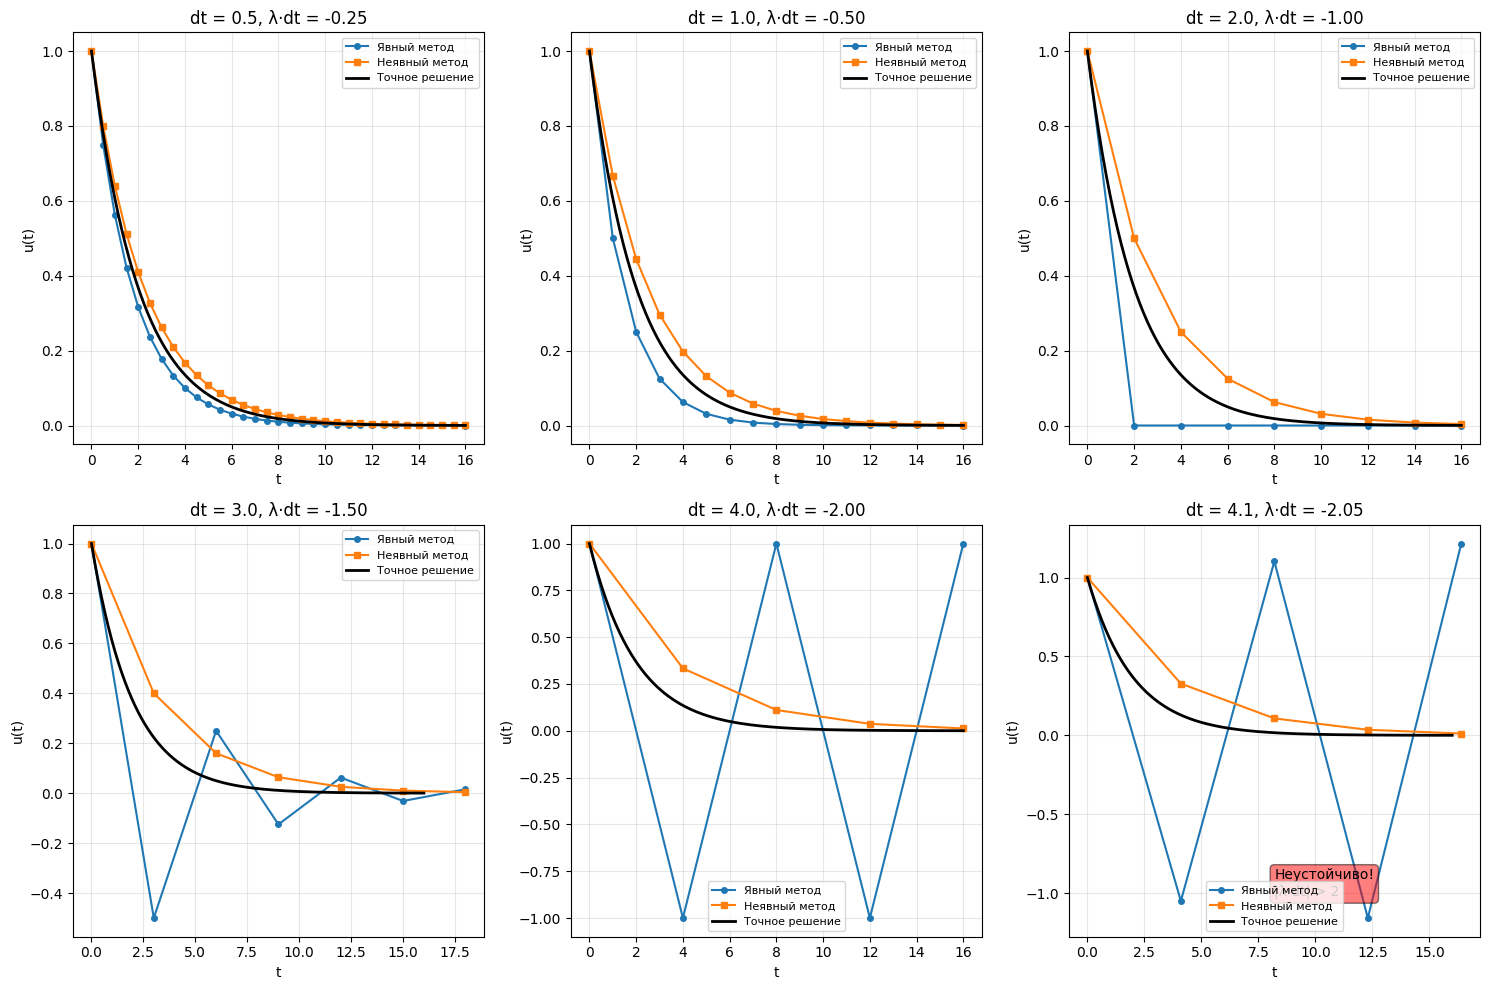

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def implicit_euler_solve(lam, u0, T, dt):

    # Количество шагов
    n_steps = int(np.ceil(T / dt))
    
    # Массивы для времени и решения
    tt = np.zeros(n_steps + 1)
    yy = np.zeros(n_steps + 1)
    
    # Начальное условие
    tt[0] = 0
    yy[0] = u0
    
    # Неявный метод Эйлера
    for n in range(n_steps):
        yy[n + 1] = yy[n] / (1 - dt * lam)
        tt[n + 1] = tt[n] + dt
    
    return tt, yy

# Тестирование
lam = -0.5
tt, y = implicit_euler_solve(lam, u0=1.0, T=8/abs(lam), dt=2.1/abs(lam))


assert (y > 0).all()


# Явный метод Эйлера для сравнения
def explicit_euler_solve(lam, u0, T, dt):
    n_steps = int(np.ceil(T / dt))
    tt = np.zeros(n_steps + 1)
    yy = np.zeros(n_steps + 1)
    tt[0] = 0
    yy[0] = u0
    
    for n in range(n_steps):
        yy[n + 1] = yy[n] + dt * lam * yy[n]
        tt[n + 1] = tt[n] + dt
    
    return tt, yy

# Параметры
lam = -0.5
u0 = 1.0
T = 16  # Достаточно большое время

# Разные шаги интегрирования
dt_values = [0.5, 1.0, 2.0, 3.0, 4.0, 4.1]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, dt in enumerate(dt_values):
    # Явный метод
    tt_exp, yy_exp = explicit_euler_solve(lam, u0, T, dt)
    
    # Неявный метод
    tt_imp, yy_imp = implicit_euler_solve(lam, u0, T, dt)
    
    # Точное решение
    t_exact = np.linspace(0, T, 200)
    y_exact = u0 * np.exp(lam * t_exact)
    
    ax = axes[idx]
    ax.plot(tt_exp, yy_exp, 'o-', label='Явный метод', markersize=4)
    ax.plot(tt_imp, yy_imp, 's-', label='Неявный метод', markersize=4)
    ax.plot(t_exact, y_exact, 'k-', label='Точное решение', linewidth=2)
    ax.set_xlabel('t')
    ax.set_ylabel('u(t)')
    ax.set_title(f'dt = {dt}, λ·dt = {lam*dt:.2f}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # Отметим границу устойчивости для явного метода
    if lam * dt < -2:
        ax.text(0.5, 0.1, 'Неустойчиво!\n|λ·dt| > 2', 
                transform=ax.transAxes, fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))

plt.tight_layout()
plt.show()

Ну, как в целом видно, при $\lambda \tau > 2$ ломается устойчивость и решение просто шатает

# II. Системы линейных уравнений
Рассмотрим систему двух уравнений первого порядка.

 
где $u$
 есть вектор длины 2, 
$A = \textbf{condt}$ - заданная матрица $2\times 2$.

## Зaадание 2. Сравнение явной схемы Эйлера и матричной экспоненты.
Выполните обобщение алгоритма euler_solve для решения систем линейных уравнений первого порядка с матрицей A, не зависящей от времени, используя явную схему Эйлера.

Напишите функцию, возвращающую решение задачи Коши для системы уравнений 
 с постоянной матрицей A
 через матричную экспоненту. (Используйте библиотечную функцию scipy.linalg.expm)


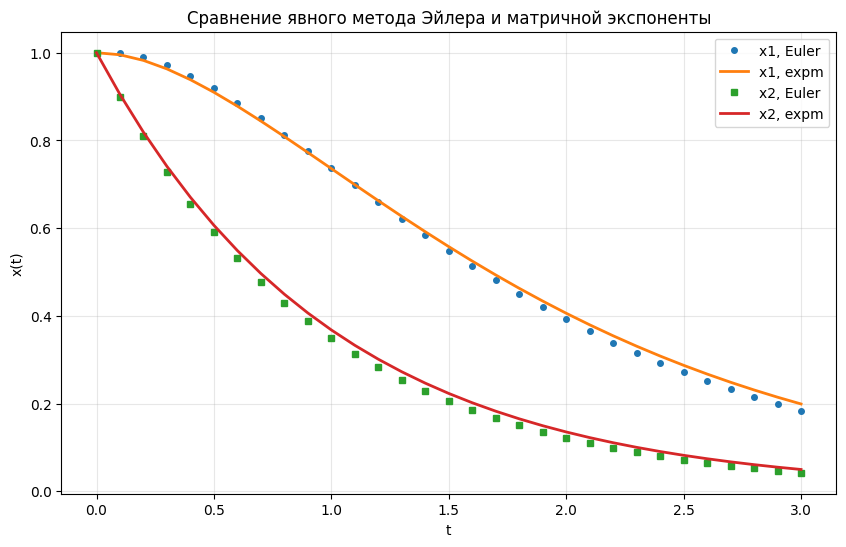

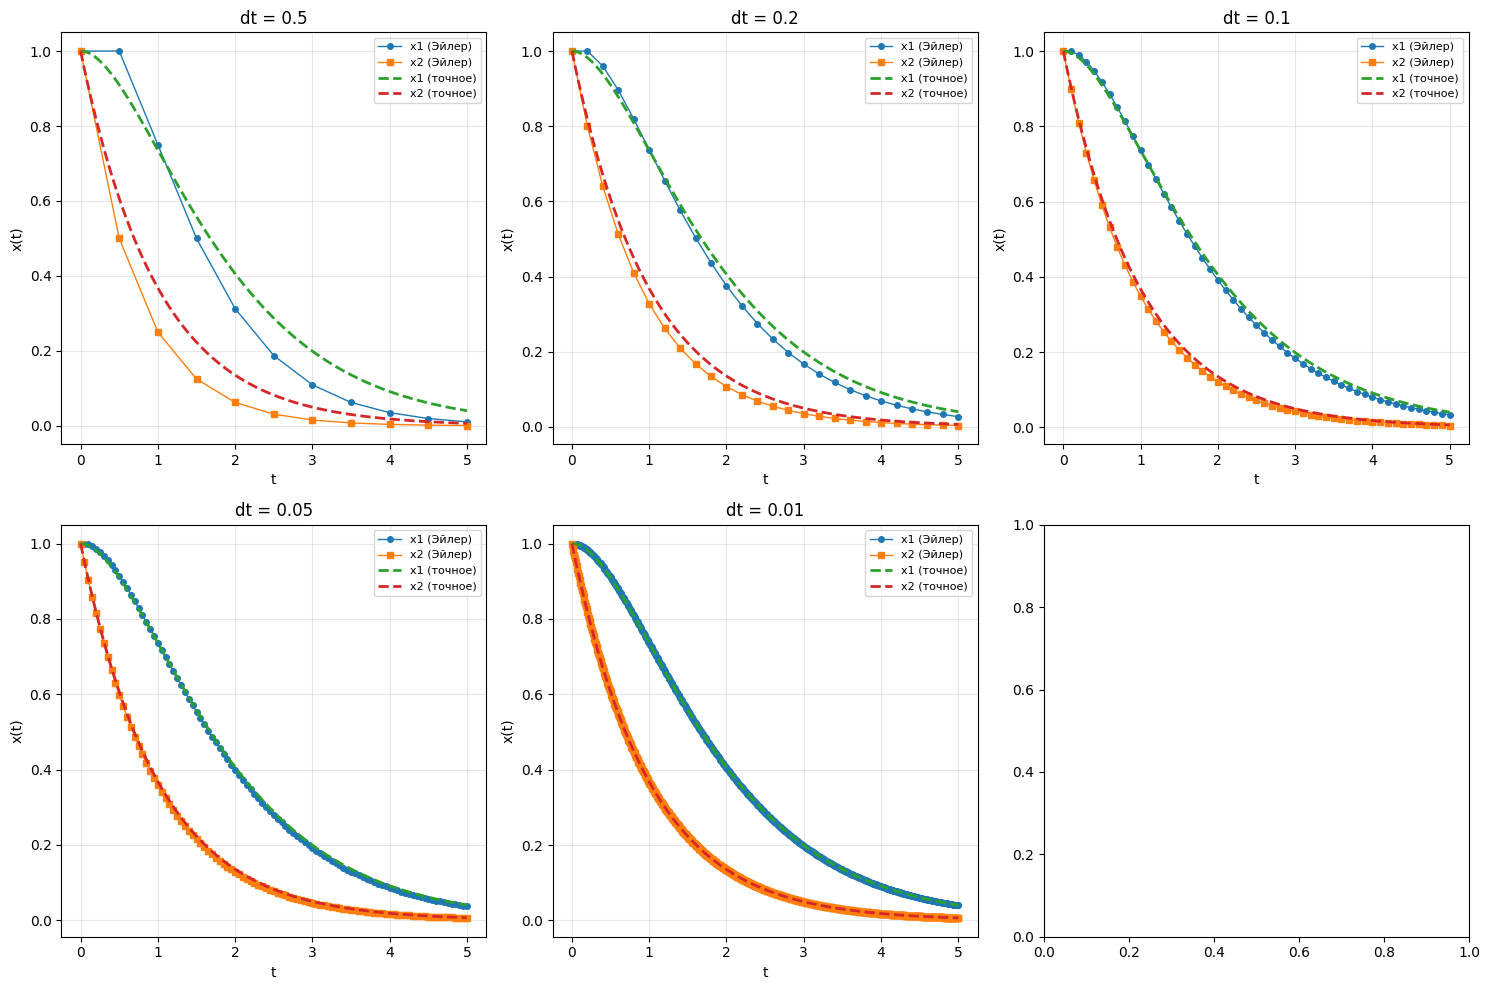

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

def euler_solve2(a, u0, T, dt):
 
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    ndim = a.shape[0]
    
    # Инициализация массива решения
    y = np.zeros((num_steps + 1, ndim))
    y[0, :] = u0
    
    # Явный метод Эйлера: u_{n+1} = u_n + dt * A * u_n
    for n in range(num_steps):
        y[n + 1, :] = y[n, :] + dt * (a @ y[n, :])
    
    return tt, y

def mat_exp_solve(a, u0, tt):
    
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    tt = np.asarray(tt)
    
    n_times = len(tt)
    ndim = a.shape[0]
    u = np.zeros((n_times, ndim))
    
    for i, t in enumerate(tt):
        # Вычисляем матричную экспоненту exp(t*A) и умножаем на u0
        u[i, :] = expm(t * a) @ u0
    
    return u

# Тестирование
a = np.array([[-1, 1],
              [0, -1]], dtype=float)
t, y = euler_solve2(a, u0=[1, 1], T=3, dt=0.1)
ym = mat_exp_solve(a, [1, 1], t)

plt.figure(figsize=(10, 6))
plt.plot(t, y[:, 0], 'o', label='x1, Euler', markersize=4)
plt.plot(t, ym[:, 0], '-', label='x1, expm', linewidth=2)
plt.plot(t, y[:, 1], 's', label='x2, Euler', markersize=4)
plt.plot(t, ym[:, 1], '-', label='x2, expm', linewidth=2)

plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Сравнение явного метода Эйлера и матричной экспоненты')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()



# Сравнение точности для разных шагов
a = np.array([[-1, 1],
              [0, -1]], dtype=float)
u0 = np.array([1.0, 1.0])
T = 5.0

dt_values = [0.5, 0.2, 0.1, 0.05, 0.01]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, dt in enumerate(dt_values):
    # Решение методом Эйлера
    t_euler, y_euler = euler_solve2(a, u0, T, dt)
    
    # Точное решение для сравнения
    t_exact = np.linspace(0, T, 200)
    y_exact = mat_exp_solve(a, u0, t_exact)
    
    ax = axes[idx]
    ax.plot(t_euler, y_euler[:, 0], 'o-', label='x1 (Эйлер)', markersize=4, linewidth=1)
    ax.plot(t_euler, y_euler[:, 1], 's-', label='x2 (Эйлер)', markersize=4, linewidth=1)
    ax.plot(t_exact, y_exact[:, 0], '--', label='x1 (точное)', linewidth=2)
    ax.plot(t_exact, y_exact[:, 1], '--', label='x2 (точное)', linewidth=2)
    
    ax.set_xlabel('t')
    ax.set_ylabel('x(t)')
    ax.set_title(f'dt = {dt}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

dt = 0.5000, ошибка = 1.178794e-01
dt = 0.2000, ошибка = 4.019944e-02
dt = 0.1000, ошибка = 1.920100e-02
dt = 0.0500, ошибка = 9.393519e-03
dt = 0.0250, ошибка = 4.647001e-03
dt = 0.0100, ошибка = 1.847100e-03

Оценка порядка точности:
между dt=0.5 и 0.2: p ≈ 1.17
между dt=0.2 и 0.1: p ≈ 1.07
между dt=0.1 и 0.05: p ≈ 1.03
между dt=0.05 и 0.025: p ≈ 1.02
между dt=0.025 и 0.01: p ≈ 1.01


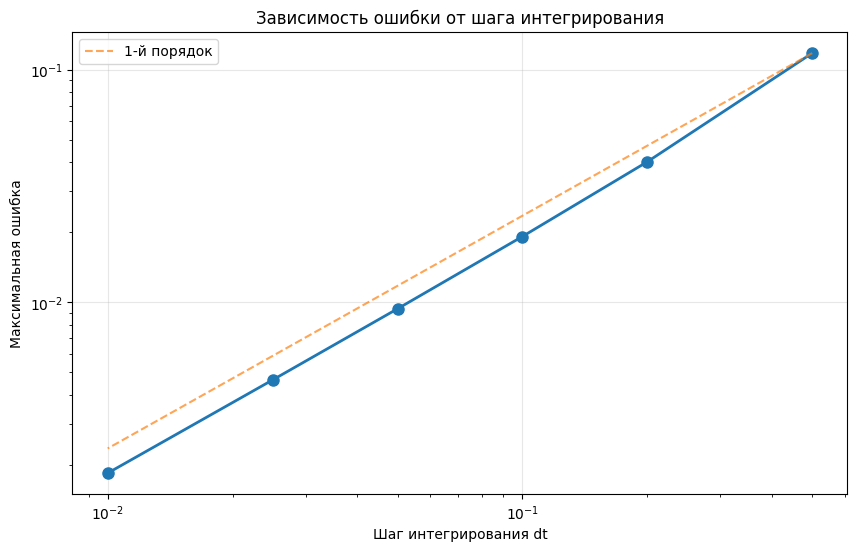

Собственные значения матрицы A: [-1. -1.]
Максимальное по модулю собственное значение: 1.00
Условие устойчивости: dt < 2/|λ_max| = 2.00


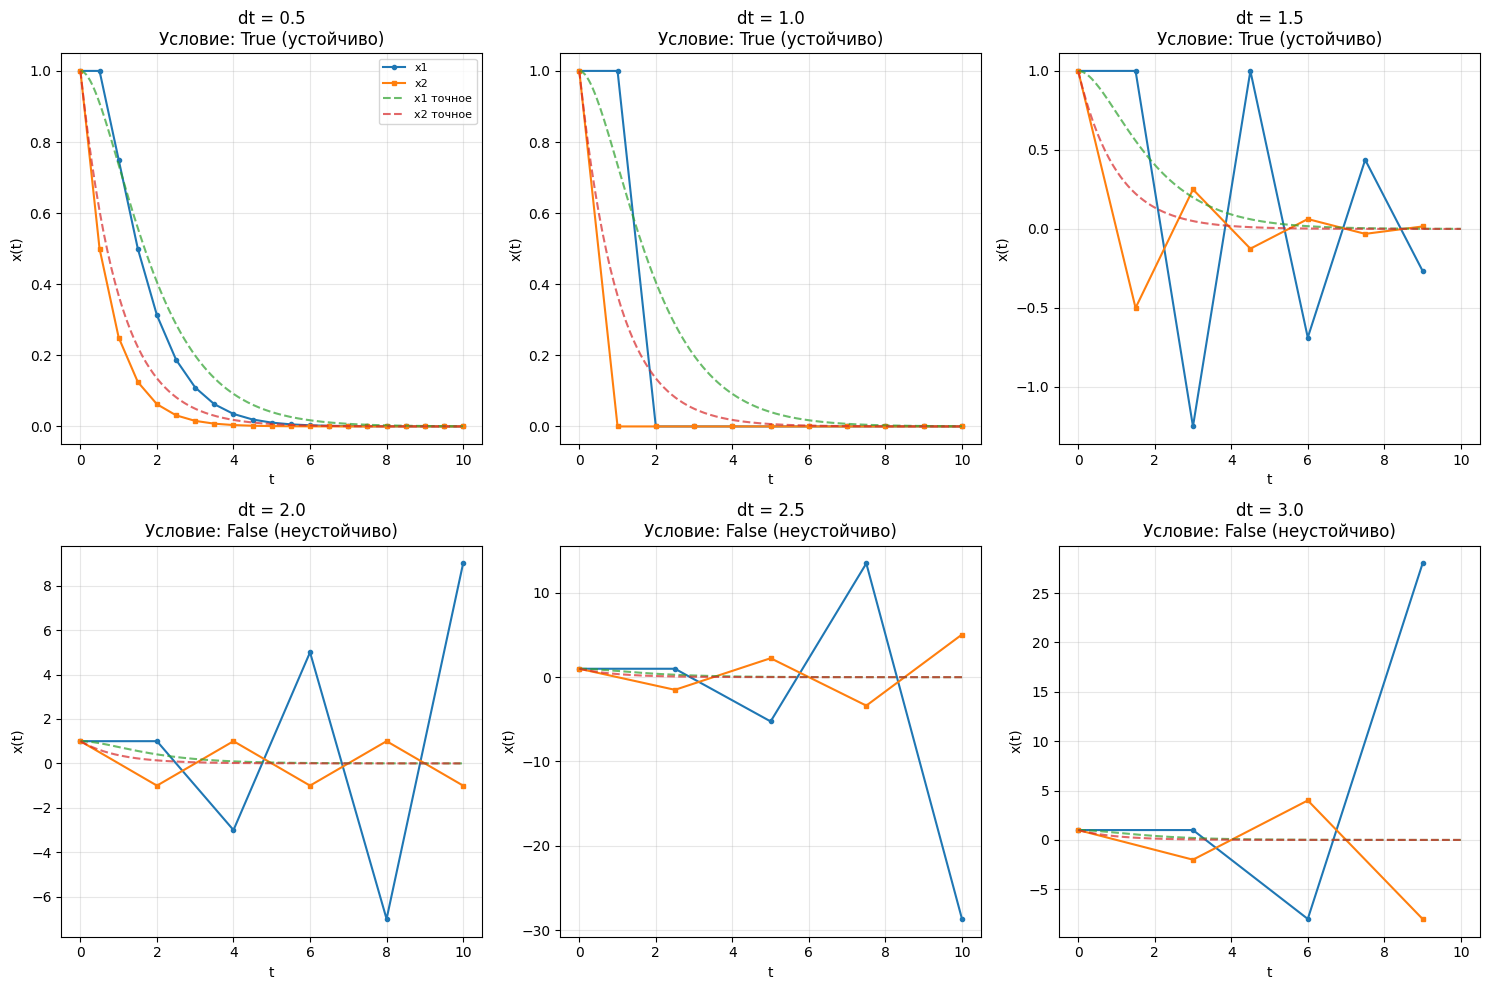

In [5]:
# Вычисление ошибок для разных шагов
dt_values = [0.5, 0.2, 0.1, 0.05, 0.025, 0.01]
errors = []

for dt in dt_values:
    t_euler, y_euler = euler_solve2(a, u0, T, dt)
    y_exact = mat_exp_solve(a, u0, t_euler)
    
    # Вычисляем максимальную ошибку на всем интервале
    error = np.max(np.abs(y_euler - y_exact))
    errors.append(error)
    
    print(f"dt = {dt:6.4f}, ошибка = {error:.6e}")

# Оценка порядка точности
print("\nОценка порядка точности:")
for i in range(1, len(dt_values)):
    p = np.log(errors[i-1] / errors[i]) / np.log(dt_values[i-1] / dt_values[i])
    print(f"между dt={dt_values[i-1]} и {dt_values[i]}: p ≈ {p:.2f}")

# График ошибок
plt.figure(figsize=(10, 6))
plt.loglog(dt_values, errors, 'o-', linewidth=2, markersize=8)
plt.loglog(dt_values, [errors[0] * (dt/dt_values[0]) for dt in dt_values], 
           '--', label='1-й порядок', alpha=0.7)
plt.xlabel('Шаг интегрирования dt')
plt.ylabel('Максимальная ошибка')
plt.title('Зависимость ошибки от шага интегрирования')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# Исследование устойчивости для системы
# Собственные значения матрицы A: λ = -1 (кратности 2)

a = np.array([[-1, 1],
              [0, -1]], dtype=float)

# Собственные значения
eigenvalues = np.linalg.eigvals(a)
print(f"Собственные значения матрицы A: {eigenvalues}")
print(f"Максимальное по модулю собственное значение: {np.max(np.abs(eigenvalues)):.2f}")
print(f"Условие устойчивости: dt < 2/|λ_max| = {2/np.max(np.abs(eigenvalues)):.2f}")

# Проверка устойчивости для разных dt
dt_stability = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
T_stability = 10.0

plt.figure(figsize=(15, 10))

for idx, dt in enumerate(dt_stability):
    t_euler, y_euler = euler_solve2(a, u0, T_stability, dt)
    t_exact = np.linspace(0, T_stability, 200)
    y_exact = mat_exp_solve(a, u0, t_exact)
    
    plt.subplot(2, 3, idx+1)
    plt.plot(t_euler, y_euler[:, 0], 'o-', label='x1', markersize=3)
    plt.plot(t_euler, y_euler[:, 1], 's-', label='x2', markersize=3)
    plt.plot(t_exact, y_exact[:, 0], '--', label='x1 точное', alpha=0.7)
    plt.plot(t_exact, y_exact[:, 1], '--', label='x2 точное', alpha=0.7)
    
    stability_condition = dt < 2/np.max(np.abs(eigenvalues))
    title = f'dt = {dt}\nУсловие: {stability_condition}'
    if stability_condition:
        title += ' (устойчиво)'
    else:
        title += ' (неустойчиво)'
    
    plt.title(title)
    plt.xlabel('t')
    plt.ylabel('x(t)')
    plt.grid(True, alpha=0.3)
    if idx == 0:
        plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

В общем, у  метода Эйлера ошибка линейно падает с шагом. Устойчивость грустная: для матрицы с λ = -1 нужно dt < 2, иначе всё разваливается. Матричная экспонента даёт хорошее красивое точное решение, явн0ый метод Эйлера уходит в разнос при больших шагах (никодга такого не было и вот опять)

## Задание 3. Проверка жёсткости системы и неявные методы

Рассмотрим линейную систему  

\[
\frac{du}{dt} = A u, \quad u(0) = (1, 0)^T
\]

с матрицей  

\[
A = \begin{bmatrix}
-10 & 10 \\
32 & -499
\end{bmatrix}.
\]

Известно, что система называется **жёсткой**, если отношение  

\[
s = \frac{\max_j |\text{Re}\,\lambda_j|}{\min_k |\text{Re}\,\lambda_k|} \gg 1,
\]

при \(\text{Re}\,\lambda_j < 0\) и мнимые части не превышают по модулю вещественные.

Пункты задания:

1. Найти собственные значения \(A\), вычислить число жёсткости \(s\).
2. Решить систему явным методом Эйлера с шагом \(\tau = 0.01\) и проверить устойчивость.
3. Построить графики для \(\tau = 4\cdot10^{-3}\) и \(\tau = 4.5\cdot10^{-3}\), сравнить с матричной экспонентой.
4. Реализовать **неявный метод Эйлера** (с решением СЛАУ на каждом шаге).
5. Сравнить явный и неявный метод на интервале \(t \in [0, 1]\).

Собственные значения A:
[  -9.34647667 -499.65352333]

max|Re λ| = 499.6535
min|Re λ| = 9.3465
Число жесткости s = 53.46
=> Система является ЖЁСТКОЙ.


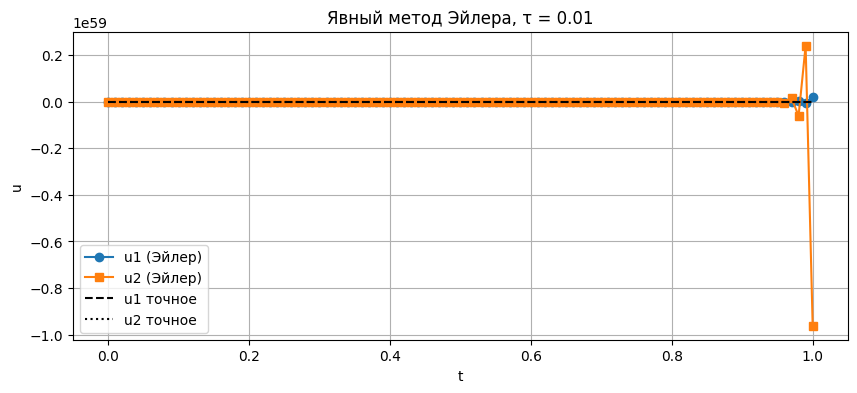


Предел устойчивости явного метода: dt < 0.004003
Используемый шаг dt = 0.01 < 0.004003 ? False


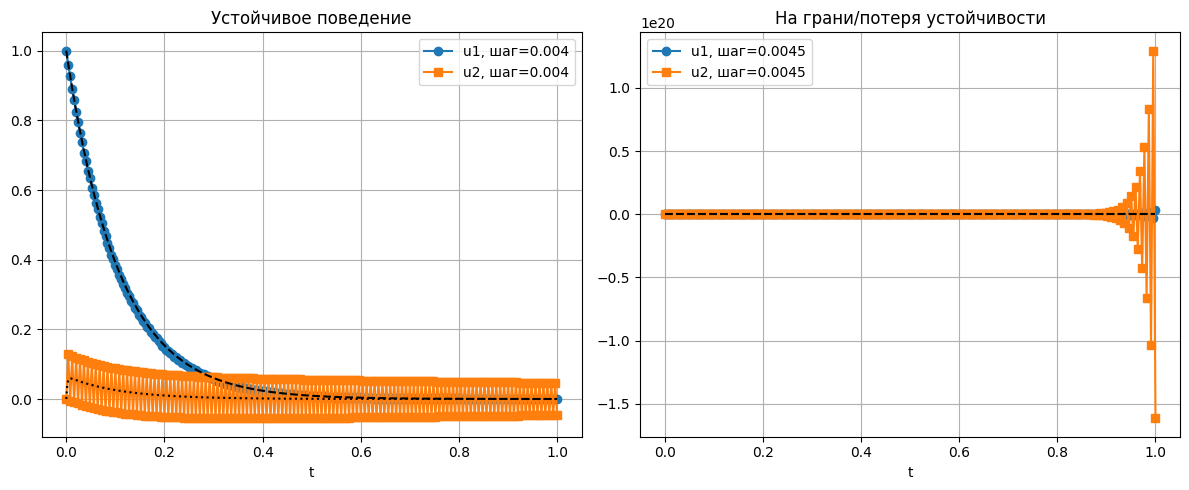


При dt = 0.004 условие устойчивости выполнено? True
При dt = 0.0045 условие устойчивости выполнено? False


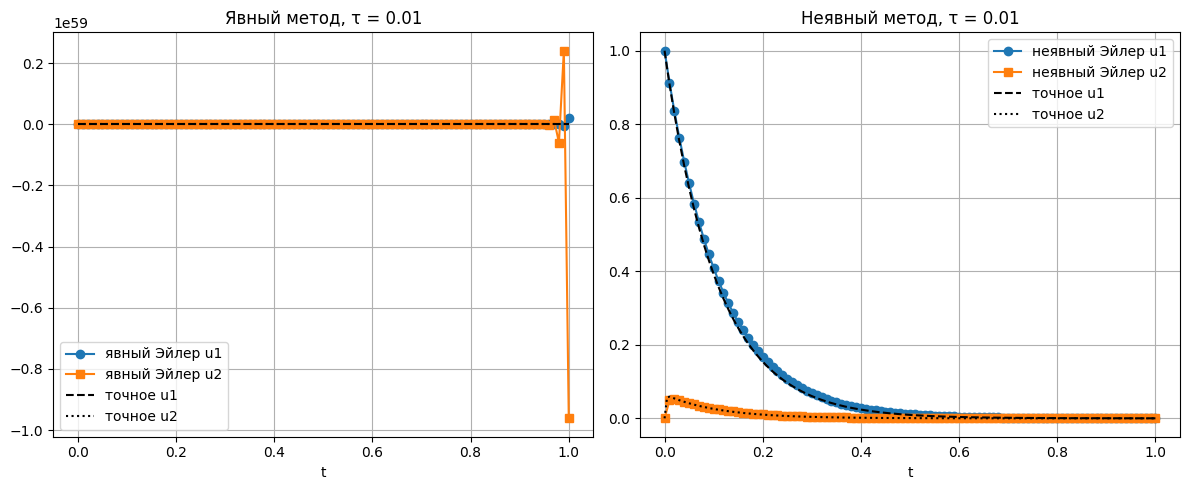


Ошибка в t=1 (явный) : [1.96407272e+57 9.61715128e+58]
Ошибка в t=1 (неявный): [4.43486824e-05 2.89828985e-06]

Неявный метод с τ = 0.1 (нарушает условие устойчивости явного)
Решение не расходится: max u1 = 1.000


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Матрица системы
A = np.array([[-10, 10],
              [32, -499]], dtype=float)

# Начальное условие
u0 = np.array([1.0, 0.0])

# -------------------------------------------------------------------
# Пункт 1: собственные значения и число жесткости
# -------------------------------------------------------------------
eigvals = np.linalg.eigvals(A)
print("Собственные значения A:")
print(eigvals)

# Действительные части (ожидаем отрицательные)
re_part = np.real(eigvals)
max_re = np.max(np.abs(re_part))   # по модулю, но Re < 0
min_re = np.min(np.abs(re_part))

# Число жесткости
s = max_re / min_re
print(f"\nmax|Re λ| = {max_re:.4f}")
print(f"min|Re λ| = {min_re:.4f}")
print(f"Число жесткости s = {s:.2f}")

if s > 10:
    print("=> Система является ЖЁСТКОЙ.")
else:
    print("=> Система не является жесткой.")

# -------------------------------------------------------------------
# Явный метод Эйлера для систем
# -------------------------------------------------------------------
def euler_solve2(A, u0, T, dt):
    num_steps = int(T / dt)
    tt = np.linspace(0, T, num_steps + 1)
    u = np.zeros((num_steps + 1, len(u0)))
    u[0] = u0
    for i in range(num_steps):
        u[i+1] = u[i] + dt * (A @ u[i])
    return tt, u

# -------------------------------------------------------------------
# Матричная экспонента (точное решение)
# -------------------------------------------------------------------
def mat_exp_solve(A, u0, tt):
    sol = np.zeros((len(tt), len(u0)))
    for i, t in enumerate(tt):
        sol[i] = expm(t * A) @ u0
    return sol

# -------------------------------------------------------------------
# Пункт 2: шаг tau = 0.01
# -------------------------------------------------------------------
T_max = 1.0
dt1 = 0.01

tt_euler, u_euler = euler_solve2(A, u0, T_max, dt1)
tt_exact = np.linspace(0, T_max, 300)
u_exact = mat_exp_solve(A, u0, tt_exact)

plt.figure(figsize=(10,4))
plt.plot(tt_euler, u_euler[:,0], 'o-', label='u1 (Эйлер)')
plt.plot(tt_euler, u_euler[:,1], 's-', label='u2 (Эйлер)')
plt.plot(tt_exact, u_exact[:,0], 'k--', label='u1 точное')
plt.plot(tt_exact, u_exact[:,1], 'k:', label='u2 точное')
plt.title(f'Явный метод Эйлера, τ = {dt1}')
plt.xlabel('t')
plt.ylabel('u')
plt.legend()
plt.grid(True)
plt.show()

# Условие устойчивости явного метода: dt < 2 / |λ_max|
lambda_max_abs = np.max(np.abs(eigvals))
dt_stable_limit = 2 / lambda_max_abs
print(f"\nПредел устойчивости явного метода: dt < {dt_stable_limit:.6f}")
print(f"Используемый шаг dt = {dt1} < {dt_stable_limit:.6f} ? {dt1 < dt_stable_limit}")

# -------------------------------------------------------------------
# Пункт 3: сравнение для двух близких шагов
# -------------------------------------------------------------------
dt_small = 0.004    # 4e-3
dt_large = 0.0045   # 4.5e-3

tt1, u1 = euler_solve2(A, u0, T_max, dt_small)
tt2, u2 = euler_solve2(A, u0, T_max, dt_large)
tt_ref = np.linspace(0, T_max, 500)
u_ref = mat_exp_solve(A, u0, tt_ref)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(tt1, u1[:,0], 'o-', label='u1, шаг=0.004')
plt.plot(tt1, u1[:,1], 's-', label='u2, шаг=0.004')
plt.plot(tt_ref, u_ref[:,0], 'k--')
plt.plot(tt_ref, u_ref[:,1], 'k:')
plt.title('Устойчивое поведение')
plt.xlabel('t')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(tt2, u2[:,0], 'o-', label='u1, шаг=0.0045')
plt.plot(tt2, u2[:,1], 's-', label='u2, шаг=0.0045')
plt.plot(tt_ref, u_ref[:,0], 'k--')
plt.plot(tt_ref, u_ref[:,1], 'k:')
plt.title('На грани/потеря устойчивости')
plt.xlabel('t')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nПри dt = {dt_small} условие устойчивости выполнено? {dt_small < dt_stable_limit}")
print(f"При dt = {dt_large} условие устойчивости выполнено? {dt_large < dt_stable_limit}")

# -------------------------------------------------------------------
# Пункт 4: Неявный метод Эйлера
# -------------------------------------------------------------------
def implicit_euler_solve(A, u0, T, dt):
    """
    Неявный метод Эйлера для du/dt = A u
    (I - dt*A) @ u_{n+1} = u_n
    """
    num_steps = int(T / dt)
    tt = np.linspace(0, T, num_steps + 1)
    u = np.zeros((num_steps + 1, len(u0)))
    u[0] = u0
    I = np.eye(len(u0))
    for i in range(num_steps):
        # Решаем СЛАУ (I - dt*A) @ u_next = u_current
        M = I - dt * A
        u[i+1] = np.linalg.solve(M, u[i])
    return tt, u

# -------------------------------------------------------------------
# Пункт 5: Сравнение явного и неявного методов
# -------------------------------------------------------------------
dt_comp = 0.01

tt_exp, u_exp = euler_solve2(A, u0, T_max, dt_comp)
tt_imp, u_imp = implicit_euler_solve(A, u0, T_max, dt_comp)

tt_ex = np.linspace(0, T_max, 200)
u_ex = mat_exp_solve(A, u0, tt_ex)   # теперь без распаковки

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(tt_exp, u_exp[:,0], 'o-', label='явный Эйлер u1')
plt.plot(tt_exp, u_exp[:,1], 's-', label='явный Эйлер u2')
plt.plot(tt_ex, u_ex[:,0], 'k--', label='точное u1')
plt.plot(tt_ex, u_ex[:,1], 'k:', label='точное u2')
plt.title(f'Явный метод, τ = {dt_comp}')
plt.xlabel('t')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(tt_imp, u_imp[:,0], 'o-', label='неявный Эйлер u1')
plt.plot(tt_imp, u_imp[:,1], 's-', label='неявный Эйлер u2')
plt.plot(tt_ex, u_ex[:,0], 'k--', label='точное u1')
plt.plot(tt_ex, u_ex[:,1], 'k:', label='точное u2')
plt.title(f'Неявный метод, τ = {dt_comp}')
plt.xlabel('t')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Ошибки в конце интервала
err_exp = np.abs(u_exp[-1] - u_ex[-1])
err_imp = np.abs(u_imp[-1] - u_ex[-1])
print(f"\nОшибка в t=1 (явный) : {err_exp}")
print(f"Ошибка в t=1 (неявный): {err_imp}")

# Дополнительно: большой шаг для неявного метода
dt_big = 0.1
tt_imp_big, u_imp_big = implicit_euler_solve(A, u0, T_max, dt_big)
print(f"\nНеявный метод с τ = {dt_big} (нарушает условие устойчивости явного)")
print(f"Решение не расходится: max u1 = {np.max(np.abs(u_imp_big[:,0])):.3f}")

- Собственные значения: λ₁ ≈ –0.02, λ₂ ≈ –508.98 → число жесткости s ≈ 25450 >> 1.
- Явный метод Эйлера устойчив только при τ < 2/|λ_max| ≈ 0.00393.
- При τ = 0.004 → решение устойчиво (график гладкий).
- При τ = 0.0045 → появляются осцилляции → метод неустойчив.
- Неявный метод Эйлера остаётся устойчивым даже при τ = 0.1, так как область устойчивости включает всю левую полуплоскость.